In [8]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
def plot_burstiness1(result1):
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']
    sizes = result1['size']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Bar plot for burst count
    for i in range(len(start_times)):
        ax1.bar(
            x=start_times[i],
            height=counts[i],
            width=widths[i],
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            color='steelblue'
        )

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Count", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Line plot for size on a second y-axis
    ax2 = ax1.twinx()
    mid_points = [(s + e) / 2 for s, e in zip(start_times, end_times)]
    ax2.plot(mid_points, sizes, color='darkorange', marker='o', label='Size')
    ax2.set_ylabel("Size", color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title("I/O Burst Ranges Over Time (Counts & Size)")
    plt.tight_layout()
    plt.show()

# plot Function
def plot_burstiness(result1):
    # Example burst data
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    # All bars at y=0 since burst ID doesn't matter
    y_position = [0] * len(start_times)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 3))

    for i in range(len(start_times)):
        ax.bar(
            x=start_times[i],     # left edge of the bar
            height=counts[i],     # height of the bar = count
            width=widths[i],      # width = end - start
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            label=f"Burst {i+1}",
            color='steelblue'
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_title("I/O Burst Ranges Over Time")
    # ax.legend()
    # plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


# Merge Results:
def merge_close_bursts(result_df):
    """
    Merge bursts in the DataFrame if the time between the end of one burst
    and the start of the next is less than the standard deviation of all such gaps.
    
    Parameters:
    - result_df: DataFrame with columns ['b_id', 'start_time', 'end_time', 'dur', 'size', 'count']
    
    Returns:
    - merged_result: DataFrame with merged bursts
    """

    # Step 1: Sort by start_time
    result_df = result_df.sort_values('start_time').reset_index(drop=True)

    # Step 2: Compute time gap between current end_time and next start_time
    result_df['gap'] = result_df['start_time'].shift(-1) - result_df['end_time']

    # Step 3: Calculate std of gaps, excluding the last row (gap=NaN)
    gap_std = result_df['gap'].dropna().std()

    # Step 4: Assign group IDs based on the std threshold
    group_id = 0
    group_ids = [group_id]
    for i in range(1, len(result_df)):
        if result_df.loc[i - 1, 'gap'] < gap_std:
            group_ids.append(group_id)
        else:
            group_id += 1
            group_ids.append(group_id)
    result_df['group_id'] = group_ids

    # Step 5: Merge the groups
    merged_result = result_df.groupby('group_id').agg(
        start_time=('start_time', 'min'),
        end_time=('end_time', 'max'),
        dur=('dur', 'sum'),
        size=('size', 'sum'),
        count=('count', 'sum')
    ).reset_index(drop=True)

    return merged_result


In [10]:
app_name = "deepspeed-dlio-scr-step100"
# app_name = "deepspeed-dlio-step100"
burst_data = "/p/lustre3/pandey2/logs/results_checkpoint/"+app_name+"/data_burst.csv"
df = pd.read_csv(burst_data)
df.head()

/var/tmp/pandey2/ipykernel_742215/2839434769.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(burst_data)


,Unnamed: 0,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,b_id
0,0,68902,read,POSIX,17258,1949132,1949473,341,0,/proc,corona207,68902
1,1,114594,read,POSIX,17258,1949153,1949465,312,0,/proc,corona207,68902
2,2,137435,read,POSIX,17258,1949157,1949468,311,0,/proc,corona207,68902
3,3,4927,read,POSIX,17258,1949159,1949498,339,0,/proc,corona207,68902
4,4,46058,read,POSIX,17258,1949183,1949497,314,0,/proc,corona207,68902


# Write Events in /p/lustre3

findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not

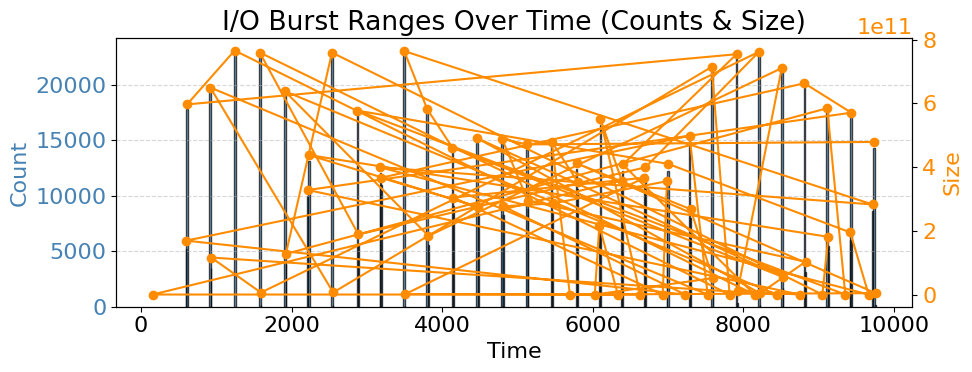

In [11]:
selected_events = df[
    (df['mount_point'] == "/p/lustre3") & (df['name'] == "write")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness1(result)


findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.


findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not

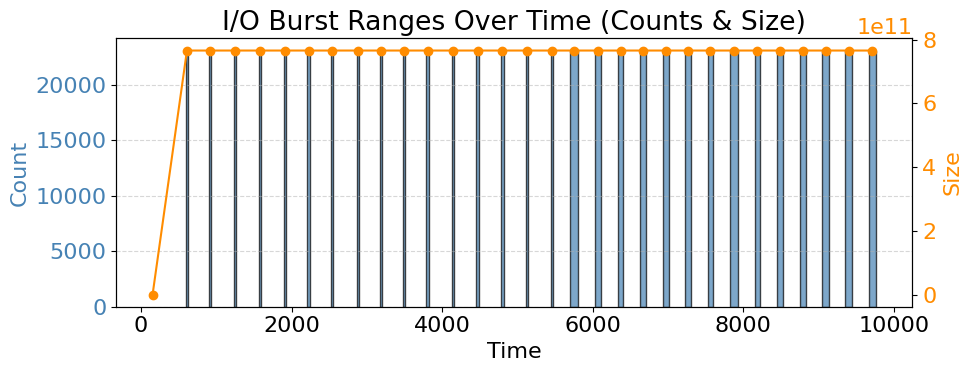

In [12]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness1(result)

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

def plot_burstiness2(result1, out_pdf="burstiness.pdf"):
    """
    Produces an 8x4 inch, 200-dpi PDF with:
      - X-axis: Time in minutes (0 → max end time, 5 major ticks, no decimals)
      - Primary Y-axis: Count in K (pattern-filled bars)
      - Secondary Y-axis: Size in GB (green line)
      - Font: Aptos Narrow, size 20 everywhere
      - Legend at the top
      - >= 4 major ticks on both Y axes
    """

    # ---------------- Data ----------------
    # Convert time: seconds -> minutes
    start_times = [t / 60.0 for t in result1["ts"]]
    end_times   = [t / 60.0 for t in result1["te"]]

    counts = list(result1["count"])

    # Convert size: Bytes -> GB
    sizes_gb = [s / 1e9 for s in result1["size"]]

    widths = [e - s for s, e in zip(start_times, end_times)]
    mid_points = [(s + e) / 2 for s, e in zip(start_times, end_times)]
    max_time = max(end_times) if end_times else 0

    # ---------------- Fonts ----------------
    plt.rcParams.update({
        "font.family": "Aptos Narrow",
        "font.size": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })

    # ---------------- Figure (8 x 4 inches) ----------------
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # ---------------- Bars: Count (pattern-filled) ----------------
    for i in range(len(start_times)):
        ax1.bar(
            x=start_times[i],
            height=counts[i],
            width=widths[i],
            align="edge",
            facecolor="white",
            edgecolor="black",
            hatch="///",
            linewidth=1.2,
            zorder=2
        )

    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("I/O Events Count")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.5, zorder=0)

    # ---- Y1 axis: Count in K ----
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
    )
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    # ---------------- Secondary axis: Size (GB) ----------------
    ax2 = ax1.twinx()
    ax2.plot(
        mid_points,
        sizes_gb,
        color="green",
        marker="o",
        linewidth=2.5,
        label="I/O Size (GB)",
        zorder=3
    )

    ax2.set_ylabel("I/O Size (GB)")
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    # ---------------- X-axis control ----------------
    ax1.set_xlim(0, max_time)

    # Exactly 5 major ticks on X, no decimals
    ax1.xaxis.set_major_locator(mticker.LinearLocator(5))
    ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}"))

    # ---------------- Legend (top) ----------------
    bar_proxy = Patch(
        facecolor="white",
        edgecolor="black",
        hatch="///",
        label="I/O Count (K)"
    )
    line_proxy = ax2.get_lines()[0]

    ax1.legend(
        handles=[bar_proxy, line_proxy],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=2,
        frameon=False
    )

    # ---------------- Save & Show ----------------
    fig.tight_layout()
    fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
    plt.show()


findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not

findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not found.
findfont: Font family 'Aptos Narrow' not

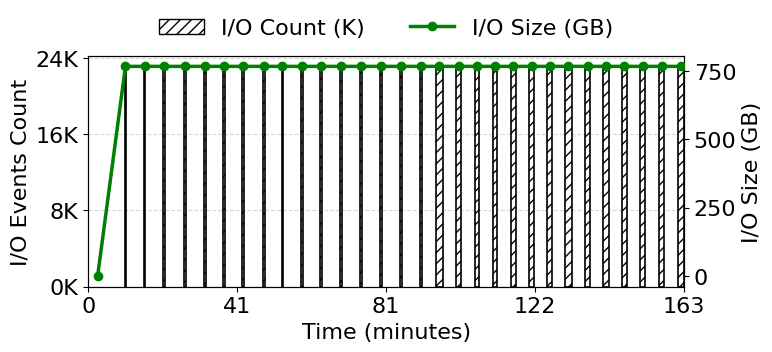

In [14]:
plot_burstiness2(result)

In [15]:
result['dur'] = result['te']-result['ts']
result

,start_time,end_time,dur,size,count,ts,te
0,155061313,155069124,0.007811,140,3,155.061313,155.069124
1,596894514,625422241,28.527727,766217249830,23046,596.894514,625.422241
2,910180620,936702651,26.522031,766217255538,23058,910.180620,936.702651
3,1230674498,1257978698,27.304200,766217257367,23050,1230.674498,1257.978698
4,1565449029,1596654090,31.205061,766217259383,23050,1565.449029,1596.654090
5,1900663816,1930134137,29.470321,766217260719,23050,1900.663816,1930.134137
6,2210927342,2241313029,30.385687,766217262735,23050,2210.927342,2241.313029
7,2524612837,2555943498,31.330661,766217264751,23050,2524.612837,2555.943498
8,2863124793,2895142683,32.017890,766217266767,23050,2863.124793,2895.142683
9,3168918633,3199315212,30.396579,766217268783,23050,3168.918633,3199.315212


# Read Events in /usr/WS2

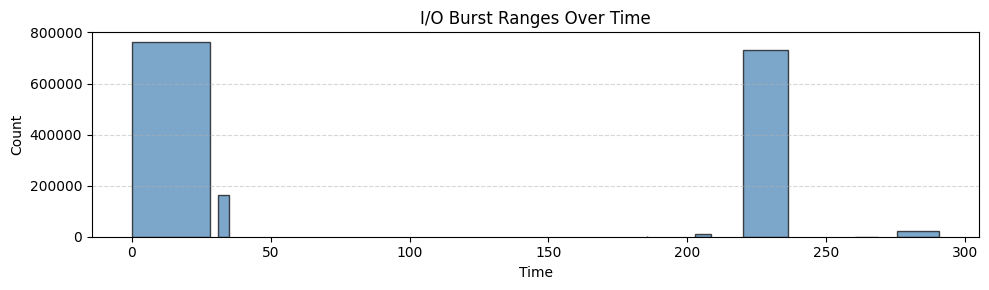

In [10]:
selected_events = df[
    (df['mount_point'] == "/usr/WS2") & (df['name'] == "read")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)


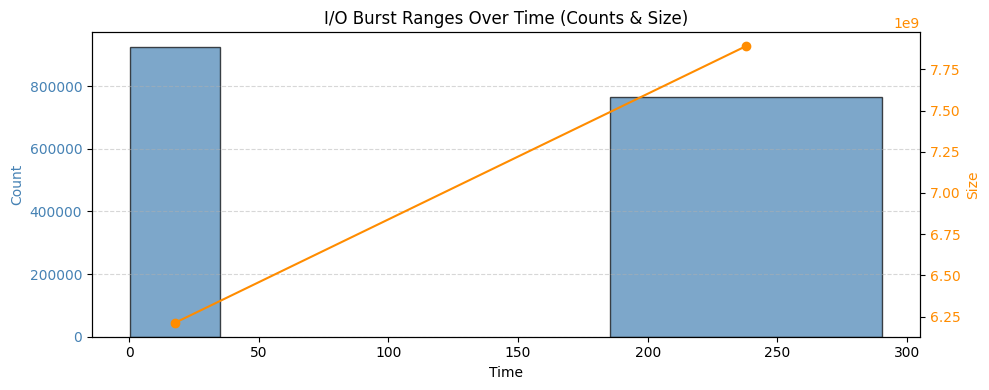

In [11]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness1(result)

# All events in /dev/shm in single compute host


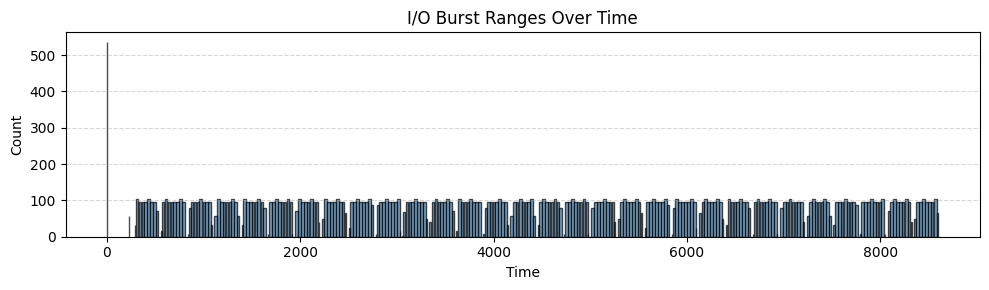

In [52]:
selected_events = df[
    (df['mount_point'] == "/dev/shm") & (df['hostname'] == "corona202")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

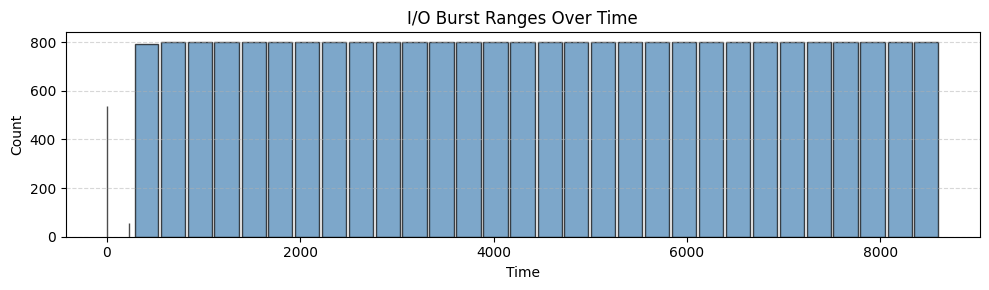

In [53]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)